<a href="https://colab.research.google.com/github/19matsiil/Tugas-Artificial-Intelligence/blob/main/(bd_dt)Linear_Log(09020624047).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
data = {
    'waktu_lihat_produk': [1,2,3,4,5,6,7,8,9,10],
    'jumlah_klik': [2,3,4,5,6,7,8,9,10,11],
    'rating_minat': [3,4,4,5,6,6,7,8,9,10],
    'beli': [0,0,0,0,1,1,1,1,1,1]
}

df = pd.DataFrame(data)
print(df)

   waktu_lihat_produk  jumlah_klik  rating_minat  beli
0                   1            2             3     0
1                   2            3             4     0
2                   3            4             4     0
3                   4            5             5     0
4                   5            6             6     1
5                   6            7             6     1
6                   7            8             7     1
7                   8            9             8     1
8                   9           10             9     1
9                  10           11            10     1


In [ ]:
x= df[['waktu_lihat_produk','jumlah_klik','rating_minat']].values
y= df['beli'].values

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
    )
#train_test_split memisahkan x (fitur) dan y (target) secara acak. Parameter test_size=0.2 berarti 20% data akan menjadi data uji, sisanya 80% menjadi data latih.
#random_state=42 digunakan agar hasil pembagian selalu sama setiap kali kode dijalankan

In [ ]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [ ]:
print("Intercept (a):", model.intercept_)
print("Koefisien (b1,b2,b3):", model.coef_)
#Kode print(model.coef_) berfungsi menampilkan tiga koefisien (b1, b2, b3) yang telah dipelajari model.
#b1 adalah pengaruh waktu lihat produk terhadap probabilitas membeli, b2 adalah pengaruh jumlah klik, dan b3 adalah pengaruh rating minat. Semakin besar nilai koefisien, semakin besar pula pengaruh fitur tersebut.

Intercept (a): [-8.89813987]
Koefisien (b1,b2,b3): [[0.62406329 0.62424012 0.5011552 ]]


In [ ]:
y_pred = model.predict(x_test)
print("prediksi : ", y_pred)
print("Aktual : ", y_test)
#memprediksi nilai dari data uji dengan model.predict(x_test), lalu menampilkan hasil prediksi (y_pred) dan membandingkannya dengan nilai penjualan sebenarnya (y_test.values)

prediksi :  [1 0]
Aktual :  [1 0]


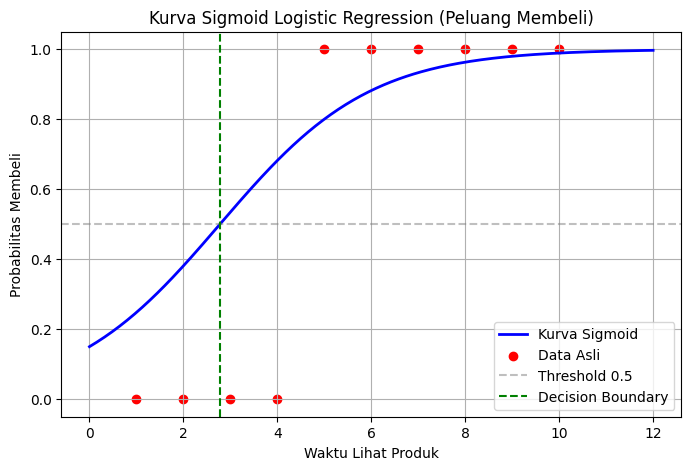

In [ ]:
mean_klik = df['jumlah_klik'].mean()
mean_rating = df['rating_minat'].mean()

waktu_range = np.linspace(0, 12, 300)

X_plot = np.column_stack([
    waktu_range,
    np.full_like(waktu_range, mean_klik),
    np.full_like(waktu_range, mean_rating)
])
prob = model.predict_proba(X_plot)[:, 1]
plt.figure(figsize=(8, 5))
plt.plot(waktu_range, prob, color='blue', linewidth=2, label='Kurva Sigmoid')
plt.scatter(df['waktu_lihat_produk'], y, color='red', label='Data Asli')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5')
idx = np.argmin(np.abs(prob - 0.5))
x_boundary = waktu_range[idx]
plt.axvline(x=x_boundary, color='green', linestyle='--', label='Decision Boundary')
plt.xlabel("Waktu Lihat Produk")
plt.ylabel("Probabilitas Membeli")
plt.title("Kurva Sigmoid Logistic Regression (Peluang Membeli)")
plt.legend()
plt.grid(True)
plt.show()


kode diatas menampilkan grafik sigmoid, dengan menghitung rata-rata jumlah klik dan rating minat agar dua fitur lainnya nilainya tetap saat waktu lihat produk divariasikan. Kemudian membuat 300 nilai waktu dari 0 sampai 12 detik, lalu menyusun data uji di mana waktu bervariasi sementara jumlah klik dan rating diset ke nilai rata-ratanya. Model menghitung probabilitas membeli untuk setiap titik waktu tersebut, menghasilkan kurva sigmoid berwarna biru. Titik-titik merah adalah data asli dari dataset. Garis putus-putus abu-abu di y=0,5 adalah ambang batas keputusan, sedangkan garis hijau vertikal menunjukkan titik keputusan di mana probabilitas tepat 0,5. Hasilnya adalah grafik yang menunjukkan semakin lama waktu lihat produk, semakin tinggi probabilitas seseorang akan membeli.

In [ ]:
import sklearn.metrics as metrics
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
#0.0 terjadi karena model memprediksi dengan sempurna pada data uji.
#Artinya, semua nilai prediksi y_pred tepat sama dengan nilai aktual y_test tanpa ada kesalahan sedikit pun.
#Mungkin karena data yang digunakan sedikit/kecil/sederhana.

MAE: 0.0
MSE: 0.0
RMSE: 0.0


In [ ]:
data_baru = [[8, 9, 7]]
prediksi = model.predict(data_baru)
print("Prediksi:", "Membeli" if prediksi[0] == 1 else "Tidak Membeli")

Prediksi: Membeli


Kode diatas digunakan untuk memprediksi satu data baru bernilai [8, 9, 7] yang mewakili waktu lihat produk 8 detik, jumlah klik 9 kali, dan rating minat 7. Model yang sudah dilatih akan memproses data tersebut melalui fungsi predict, lalu hasilnya (0 atau 1) diperiksa dengan kondisi if else; jika bernilai 1 maka mencetak "Membeli", sebaliknya mencetak "Tidak Membeli"